[Reference](https://docs.scipy.org/doc/scipy/reference/)

#Import

In [1]:
#pip install scipy
import scipy
print(scipy.__version__)

1.11.4


#Constants

In [2]:
from scipy.constants import c,h
print(f"Speed of light : {c}m/s")

print(f"Planck's constant: {h}J*s")

Speed of light : 299792458.0m/s
Planck's constant: 6.62607015e-34J*s


In [3]:
from scipy.constants import physical_constants

In [4]:
# List all physical constants
for key, value in physical_constants.items():
    print(f"{key}: {value[0]} {value[1]}")

Wien displacement law constant: 0.0028977685 m K
atomic unit of 1st hyperpolarizablity: 3.20636151e-53 C^3 m^3 J^-2
atomic unit of 2nd hyperpolarizablity: 6.2353808e-65 C^4 m^4 J^-3
atomic unit of electric dipole moment: 8.47835309e-30 C m
atomic unit of electric polarizablity: 1.648777274e-41 C^2 m^2 J^-1
atomic unit of electric quadrupole moment: 4.48655124e-40 C m^2
atomic unit of magn. dipole moment: 1.8548019e-23 J T^-1
atomic unit of magn. flux density: 235051.756758 T
deuteron magn. moment: 4.33073482e-27 J T^-1
deuteron magn. moment to Bohr magneton ratio: 0.0004669754567 
deuteron magn. moment to nuclear magneton ratio: 0.8574382329 
deuteron-electron magn. moment ratio: -0.0004664345548 
deuteron-proton magn. moment ratio: 0.3070122084 
deuteron-neutron magn. moment ratio: -0.44820652 
electron gyromagn. ratio: 176085963023.0 s^-1 T^-1
electron gyromagn. ratio over 2 pi: 28024.9532 MHz T^-1
electron magn. moment: -9.28476412e-24 J T^-1
electron magn. moment to Bohr magneton r

#Integration and differentiation

In [7]:
from scipy.integrate import quad, odeint
import numpy as np

# Numerical integration
def integrand(x):
    return np.exp(-x**2)

result, error = quad(integrand, 0, np.inf)
print(f"Integral result: {result}, error: {error}")




Integral result: 0.8862269254527579, error: 7.101318390472462e-09


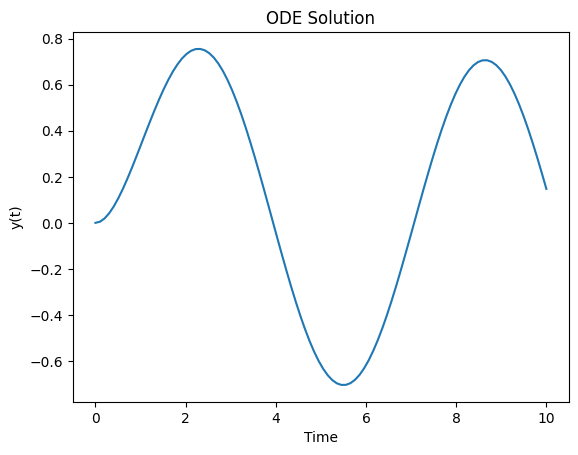

In [8]:
# Solving ODE
def model(y, t):
    dydt = -y + np.sin(t)
    return dydt

y0 = 0
t = np.linspace(0, 10, 100)
solution = odeint(model, y0, t)

import matplotlib.pyplot as plt
plt.plot(t, solution)
plt.xlabel('Time')
plt.ylabel('y(t)')
plt.title('ODE Solution')
plt.show()

#Interpolation

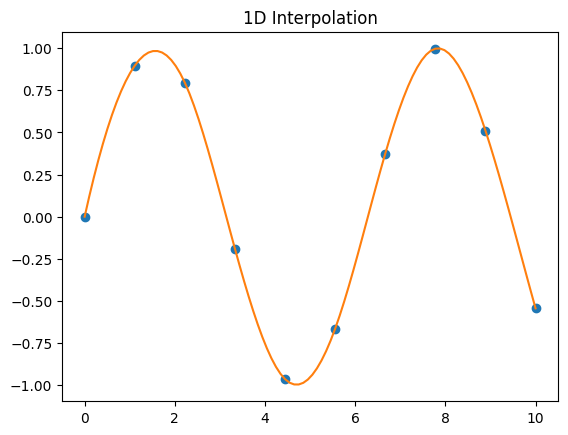

In [10]:
from scipy.interpolate import interp1d

# 1D interpolation
x = np.linspace(0, 10, 10)
y = np.sin(x)
f = interp1d(x, y, kind='cubic')

x_new = np.linspace(0, 10, 100)
y_new = f(x_new)

plt.plot(x, y, 'o', x_new, y_new, '-')
plt.title('1D Interpolation')
plt.show()




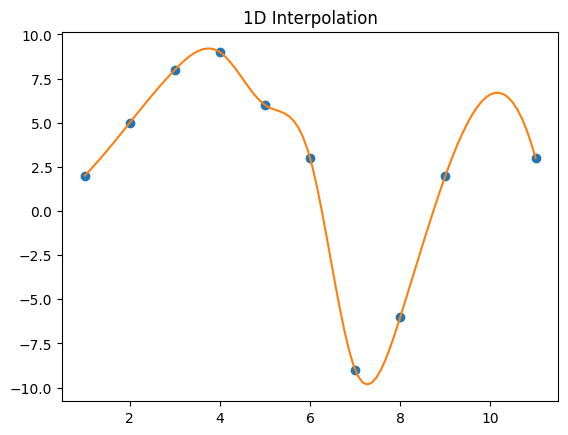

In [23]:
x = np.array([1,2,3,4,5,6,7,8,9,11])
y = np.array([2,5,8,9,6,3,-9,-6,2,3])
f = interp1d(x, y, kind='cubic')

x_new = np.linspace(1, 11, 100)
y_new = f(x_new)

plt.plot(x, y, 'o', x_new, y_new, '-')
plt.title('1D Interpolation')
plt.show()

#Optimization

In [24]:
from scipy.optimize import minimize, root

# Function to minimize
def objective(x):
    return x**2 + 10*np.sin(x)

result = minimize(objective, x0=0)
print(f"Minimum value: {result.x}, Objective function value: {result.fun}")




Minimum value: [-1.30644012], Objective function value: -7.945823375615215
Root: [1.]


In [25]:
# Root finding
def equation(x):
    return x**3 - 1

sol = root(equation, x0=0.5)
print(f"Root: {sol.x}")

Root: [1.]


#Signal processing

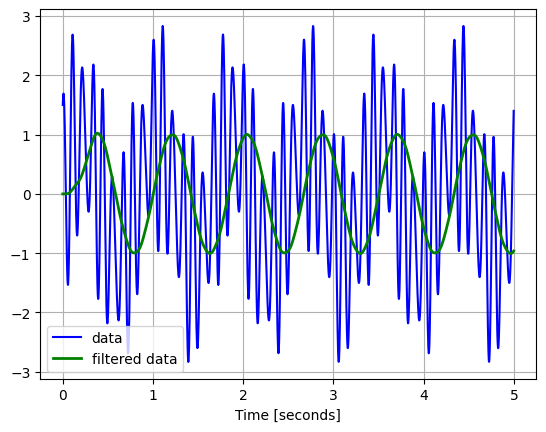

In [48]:
from scipy.signal import butter, lfilter, freqz
from scipy.fft import fft, fftfreq

# Butterworth filter
def butter_lowpass(cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def butter_lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = lfilter(b, a, data)
    return y

# Generate a noisy signal
T = 5
nsamples = T * 500
t = np.linspace(0, T, nsamples, endpoint=False)
data = np.sin(1.2*2*np.pi*t) + 1.5*np.cos(9*2*np.pi*t) + 0.5*np.sin(12.0*2*np.pi*t)

# Filter the signal
order = 6
fs = 500.0
cutoff = 3.667
filtered_data = butter_lowpass_filter(data, cutoff, fs, order)

# plt.subplot(2, 1, 1)
plt.plot(t, data, 'b-', label='data')
plt.plot(t, filtered_data, 'g-', linewidth=2, label='filtered data')
plt.xlabel('Time [seconds]')
plt.grid()
plt.legend()
plt.show()





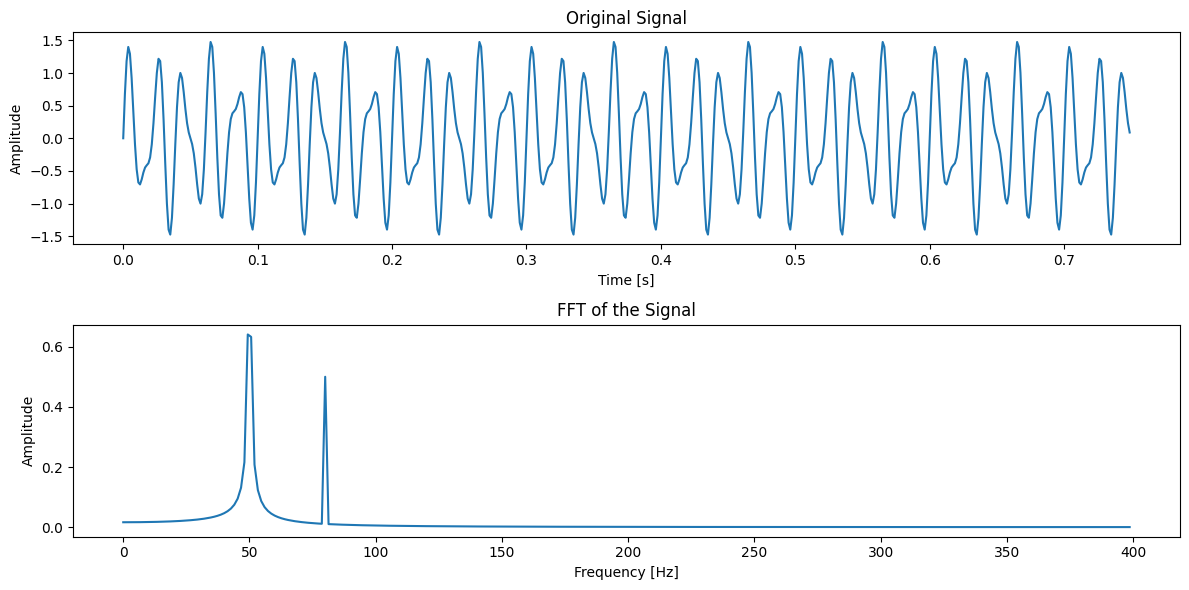

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Generate a sample signal
# Parameters
N = 600            # Number of sample points
T = 1.0 / 800.0    # Sample spacing (time between samples)

# Time vector
x = np.linspace(0.0, N*T, N, endpoint=False)

# Signal: a sum of two sine waves with different frequencies
y = np.sin(50.0 * 2.0 * np.pi * x) + 0.5 * np.sin(80.0 * 2.0 * np.pi * x)

# Compute the FFT
yf = fft(y)

# Compute the corresponding frequencies
xf = fftfreq(N, T)[:N//2]

# Plot the original signal
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(x, y)
plt.title("Original Signal")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

# Plot the FFT result
plt.subplot(2, 1, 2)
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.title("FFT of the Signal")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()


#Statistics

In [33]:
from scipy.stats import ttest_ind, describe

# Generate two random samples
np.random.seed(0)
sample1 = np.random.normal(loc=0, scale=1, size=100)
sample2 = np.random.normal(loc=0.5, scale=1.5, size=100)

# Descriptive statistics
desc1 = describe(sample1)
desc2 = describe(sample2)
print(f"Sample 1: {desc1}")
print(f"Sample 2: {desc2}")

# T-test
t_stat, p_value = ttest_ind(sample1, sample2)
print(f"T-test result: t_stat={t_stat}, p_value={p_value}")


Sample 1: DescribeResult(nobs=100, minmax=(-2.5529898158340787, 2.2697546239876076), mean=0.059808015534485, variance=1.0260874941564964, skewness=0.005171839713550013, kurtosis=-0.3783545566331328)
Sample 2: DescribeResult(nobs=100, minmax=(-2.83510472833664, 4.074717162295913), mean=0.623019456121756, variance=2.433035899064184, skewness=0.20944900249999465, kurtosis=-0.8089238933309688)
T-test result: t_stat=-3.0282270946236767, p_value=0.002787453117267857


In [34]:
from scipy.stats import describe

# Generate random data
data = np.random.normal(loc=0, scale=1, size=1000)

# Descriptive statistics
desc = describe(data)
print(f"Number of observations: {desc.nobs}")
print(f"Min-max: {desc.minmax}")
print(f"Mean: {desc.mean}")
print(f"Variance: {desc.variance}")
print(f"Skewness: {desc.skewness}")
print(f"Kurtosis: {desc.kurtosis}")


Number of observations: 1000
Min-max: (-3.0461430547999266, 3.1709747732901796)
Mean: -0.04022325854455201
Variance: 0.9381633458171817
Skewness: 0.011362317926249832
Kurtosis: 0.0962426455486689


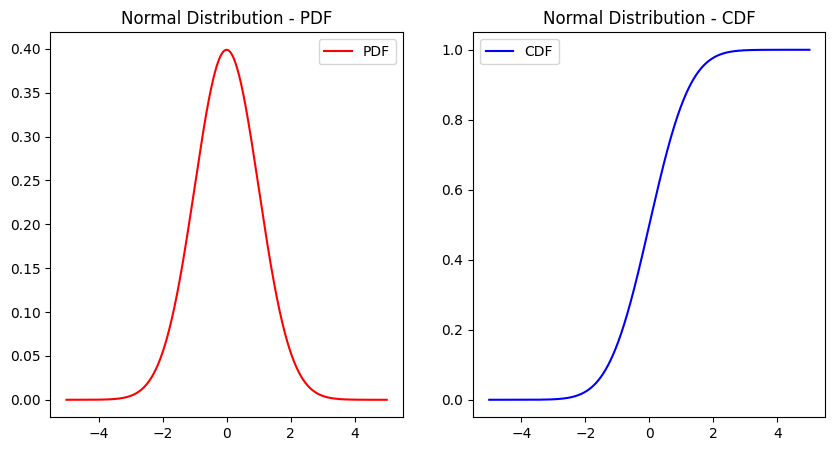

In [35]:
from scipy.stats import norm

# Parameters for normal distribution
mean, std_dev = 0, 1

# Probability density function (PDF)
x = np.linspace(-5, 5, 1000)
pdf = norm.pdf(x, mean, std_dev)

# Cumulative distribution function (CDF)
cdf = norm.cdf(x, mean, std_dev)

# Plotting PDF and CDF
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x, pdf, 'r-', label='PDF')
plt.title('Normal Distribution - PDF')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x, cdf, 'b-', label='CDF')
plt.title('Normal Distribution - CDF')
plt.legend()

plt.show()


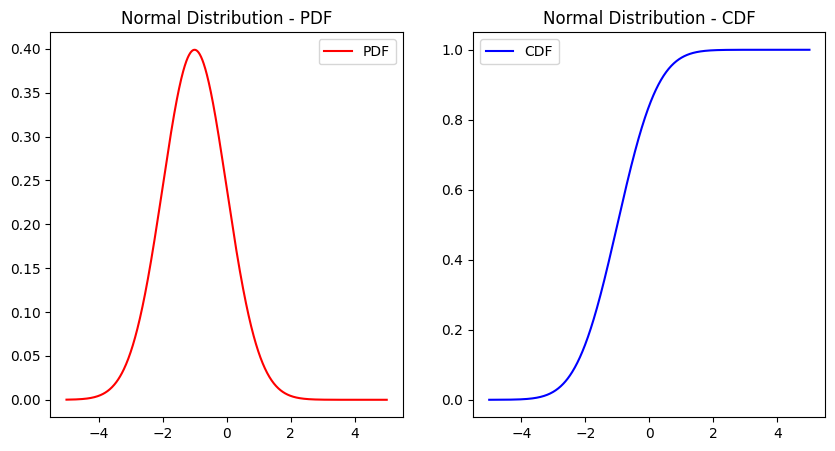

In [36]:


# Parameters for normal distribution
mean, std_dev = -1, 1

# Probability density function (PDF)
x = np.linspace(-5, 5, 1000)
pdf = norm.pdf(x, mean, std_dev)

# Cumulative distribution function (CDF)
cdf = norm.cdf(x, mean, std_dev)

# Plotting PDF and CDF
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x, pdf, 'r-', label='PDF')
plt.title('Normal Distribution - PDF')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x, cdf, 'b-', label='CDF')
plt.title('Normal Distribution - CDF')
plt.legend()

plt.show()


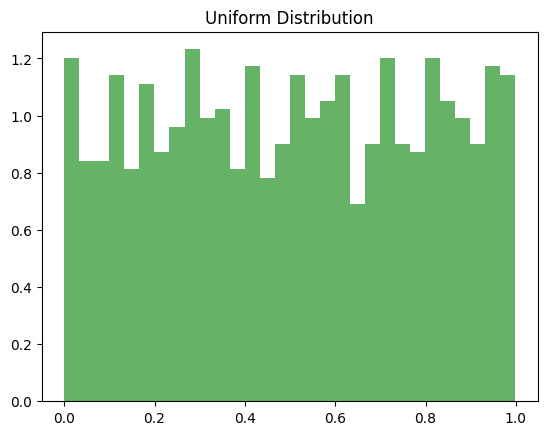

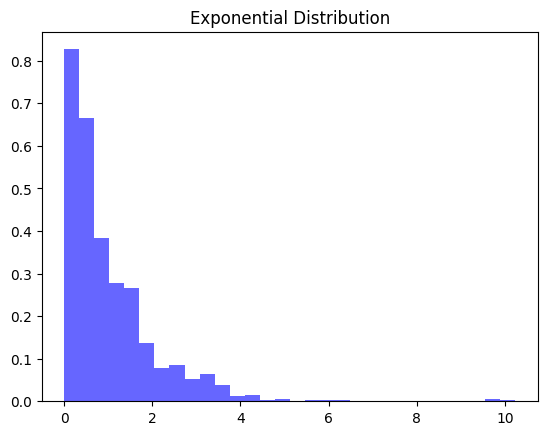

In [37]:
from scipy.stats import uniform, expon

# Uniform Distribution
a, b = 0, 1
uniform_data = uniform.rvs(a, b, size=1000)
plt.hist(uniform_data, bins=30, density=True, alpha=0.6, color='g')
plt.title('Uniform Distribution')
plt.show()

# Exponential Distribution
scale = 1
expon_data = expon.rvs(scale=scale, size=1000)
plt.hist(expon_data, bins=30, density=True, alpha=0.6, color='b')
plt.title('Exponential Distribution')
plt.show()


In [40]:
from scipy.stats import chisquare

expected = np.array([44, 24, 29, 3]) / 100 * 189
observed = np.array([43, 52, 54, 40])

# Chi-square test
chi_stat, p_value = chisquare(f_obs=observed, f_exp=expected)
print(f"Chi-square test: chi_stat={chi_stat}, p_value={p_value}")


Chi-square test: chi_stat=228.23515947653874, p_value=3.3295585338846486e-49


In [41]:
from scipy.stats import f_oneway

# Generate three samples
np.random.seed(0)
sample1 = np.random.normal(loc=0, scale=1, size=100)
sample2 = np.random.normal(loc=0.5, scale=1, size=100)
sample3 = np.random.normal(loc=1, scale=1, size=100)

# ANOVA
f_stat, p_value = f_oneway(sample1, sample2, sample3)
print(f"ANOVA: f_stat={f_stat}, p_value={p_value}")


ANOVA: f_stat=19.476212850706954, p_value=1.1274108620248838e-08


In [42]:
from scipy.stats import pearsonr

# Generate two random samples
np.random.seed(0)
x = np.random.normal(loc=0, scale=1, size=100)
y = x + np.random.normal(loc=0, scale=0.1, size=100)

# Pearson correlation
corr, p_value = pearsonr(x, y)
print(f"Pearson correlation: corr={corr}, p_value={p_value}")


Pearson correlation: corr=0.9949523162169297, p_value=1.1365303743040459e-99


In [43]:
from scipy.stats import spearmanr

# Spearman correlation
corr, p_value = spearmanr(x, y)
print(f"Spearman correlation: corr={corr}, p_value={p_value}")


Spearman correlation: corr=0.9901950195019501, p_value=1.3683213820080855e-85


Slope: 1.993693502140204
Intercept: 1.0222151077447226
R-squared: 0.9708365512617755
P-value: 4.882259557883748e-77
Standard error: 0.034905329044140336


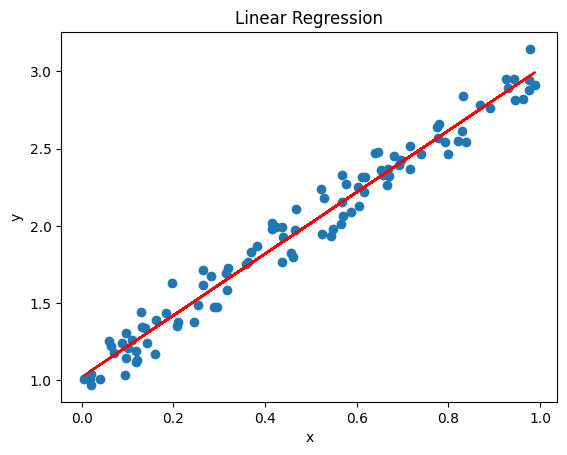

In [44]:
from scipy.stats import linregress

# Generate random data
np.random.seed(0)
x = np.random.rand(100)
y = 2 * x + 1 + np.random.normal(0, 0.1, 100)

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")
print(f"P-value: {p_value}")
print(f"Standard error: {std_err}")

# Plotting the regression line
plt.scatter(x, y)
plt.plot(x, slope*x + intercept, 'r')
plt.title('Linear Regression')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


Fitted parameters (Normal distribution): mean=-0.044441650781114846, std=0.9712764227220764


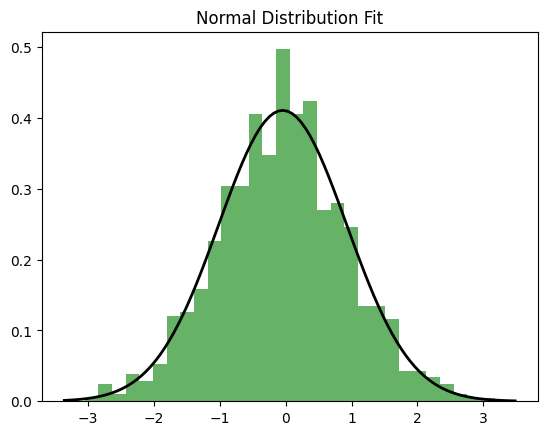

Fitted parameters (Exponential distribution): loc=0.00014740429808550413, scale=2.0319865902861944


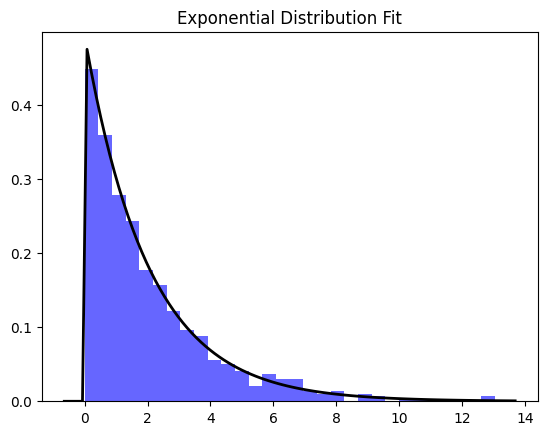

In [45]:
from scipy.stats import norm, expon

# Generate random data
data = np.random.normal(loc=0, scale=1, size=1000)

# Fit data to normal distribution
mu, std = norm.fit(data)
print(f"Fitted parameters (Normal distribution): mean={mu}, std={std}")

# Plot the histogram and the PDF
plt.hist(data, bins=30, density=True, alpha=0.6, color='g')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)
plt.title('Normal Distribution Fit')
plt.show()

# Generate random data for exponential distribution
data = np.random.exponential(scale=2, size=1000)

# Fit data to exponential distribution
loc, scale = expon.fit(data)
print(f"Fitted parameters (Exponential distribution): loc={loc}, scale={scale}")

# Plot the histogram and the PDF
plt.hist(data, bins=30, density=True, alpha=0.6, color='b')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = expon.pdf(x, loc, scale)
plt.plot(x, p, 'k', linewidth=2)
plt.title('Exponential Distribution Fit')
plt.show()
